<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_address_collision_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

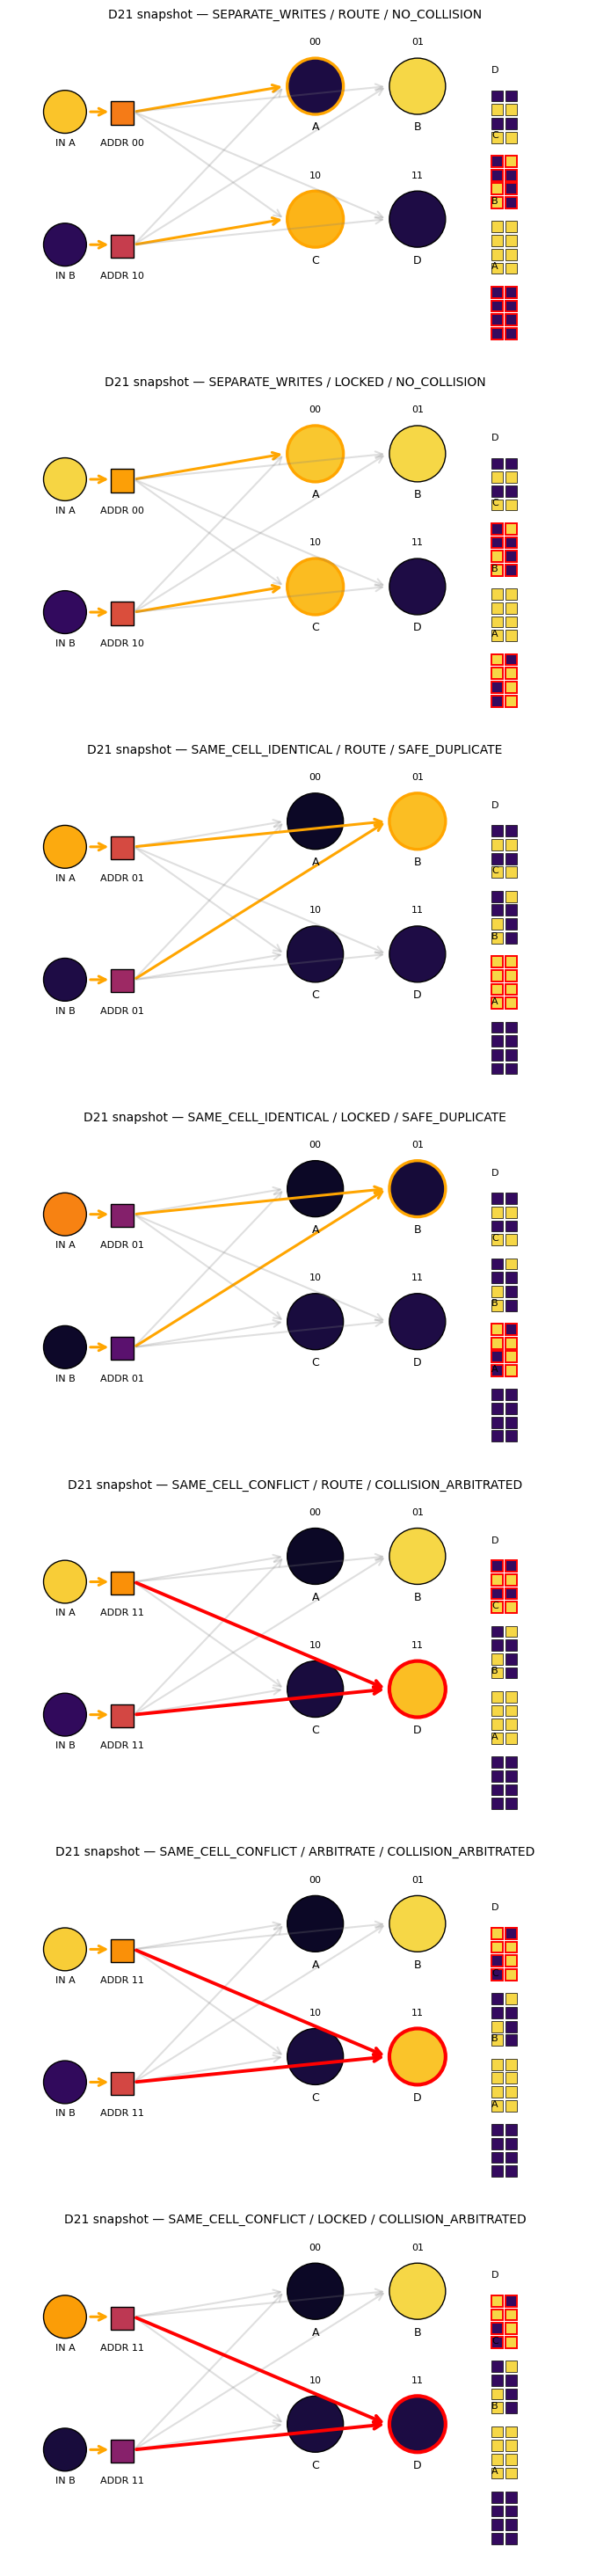

STATE: ADDRESS_COLLISION_LOCKED
cases tested:              3
locked cases:              3
priority writer:           A
mean isolation accuracy:   1.0
mean write accuracy A:     1.0
mean write accuracy B:     0.667

Collision case table:


,STATE,CASE,RESULT,BUS_RESULT,INPUT_A,ADDR_A,DECODED_ADDR_A,CELL_A,INPUT_B,ADDR_B,DECODED_ADDR_B,CELL_B,SAME_ADDRESS,SAME_PAYLOAD,COLLISION,WINNER,WRITE_ACCURACY_A,WRITE_ACCURACY_B,ISOLATION_ACCURACY
0,D21_ADDRESS_COLLISION_TEST,SEPARATE_WRITES,COLLISION_TEST_LOCKED,NO_COLLISION,10110101,00,00,MEM_CELL_A,01001010,10,10,MEM_CELL_C,0,0,0,A+B,1.0,1.0,1.0
1,D21_ADDRESS_COLLISION_TEST,SAME_CELL_IDENTICAL,COLLISION_TEST_LOCKED,SAFE_DUPLICATE,10110101,01,01,MEM_CELL_B,10110101,01,01,MEM_CELL_B,1,1,0,A+B,1.0,1.0,1.0
2,D21_ADDRESS_COLLISION_TEST,SAME_CELL_CONFLICT,COLLISION_TEST_LOCKED,COLLISION_ARBITRATED,10110101,11,11,MEM_CELL_D,01001010,11,11,MEM_CELL_D,1,0,1,A,1.0,0.0,1.0



Final summary:


,STATE,RESULT,CASES_TESTED,LOCKED_CASES,PRIORITY_WRITER,MEAN_ISOLATION_ACCURACY,MEAN_WRITE_ACCURACY_A,MEAN_WRITE_ACCURACY_B
0,D21_ADDRESS_COLLISION_TEST,ADDRESS_COLLISION_LOCKED,3,3,A,1.0,1.0,0.667


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch

# ============================================================
# D21_ADDRESS_COLLISION_TEST
# Routed memory bus collision and arbitration test
#
# Goal:
# two input waves
# -> two address decoders
# -> simultaneous routed writes
# -> detect same-address collision
# -> allow safe writes when addresses differ
# -> resolve conflict by deterministic priority arbitration
# ============================================================

np.random.seed(21)

STATE = "D21_ADDRESS_COLLISION_TEST"

decode_threshold = 0.50

address_map = {
    "00": "MEM_CELL_A",
    "01": "MEM_CELL_B",
    "10": "MEM_CELL_C",
    "11": "MEM_CELL_D",
}

memory_initial = {
    "MEM_CELL_A": "00000000",
    "MEM_CELL_B": "11111111",
    "MEM_CELL_C": "01001010",
    "MEM_CELL_D": "00110011",
}

test_cases = [
    {
        "CASE": "SEPARATE_WRITES",
        "INPUT_A": "10110101",
        "ADDR_A": "00",
        "INPUT_B": "01001010",
        "ADDR_B": "10",
        "EXPECTED_RESULT": "NO_COLLISION"
    },
    {
        "CASE": "SAME_CELL_IDENTICAL",
        "INPUT_A": "10110101",
        "ADDR_A": "01",
        "INPUT_B": "10110101",
        "ADDR_B": "01",
        "EXPECTED_RESULT": "SAFE_DUPLICATE"
    },
    {
        "CASE": "SAME_CELL_CONFLICT",
        "INPUT_A": "10110101",
        "ADDR_A": "11",
        "INPUT_B": "01001010",
        "ADDR_B": "11",
        "EXPECTED_RESULT": "COLLISION_ARBITRATED"
    },
]

priority_writer = "A"


def seq_to_bits(seq):
    return [int(x) for x in seq]


def bits_to_string(bits):
    return "".join(str(int(x)) for x in bits)


def accuracy(a, b):
    return float(np.mean(np.array(seq_to_bits(a)) == np.array(seq_to_bits(b))))


def decode_address(address_bits):
    received = []
    for bit in address_bits:
        if bit == "1":
            value = 0.74 + np.random.normal(0, 0.035)
        else:
            value = 0.21 + np.random.normal(0, 0.035)
        received.append(float(np.clip(value, 0.0, 1.0)))

    decoded = bits_to_string([1 if v >= decode_threshold else 0 for v in received])
    return decoded, received


def run_case(case):
    memory_before = memory_initial.copy()
    memory_after = memory_before.copy()

    decoded_a, recv_a = decode_address(case["ADDR_A"])
    decoded_b, recv_b = decode_address(case["ADDR_B"])

    cell_a = address_map[decoded_a]
    cell_b = address_map[decoded_b]

    address_a_locked = decoded_a == case["ADDR_A"]
    address_b_locked = decoded_b == case["ADDR_B"]

    same_address = cell_a == cell_b
    same_payload = case["INPUT_A"] == case["INPUT_B"]

    collision = same_address and not same_payload

    if not same_address:
        memory_after[cell_a] = case["INPUT_A"]
        memory_after[cell_b] = case["INPUT_B"]
        bus_result = "NO_COLLISION"
        winner = "A+B"

    elif same_address and same_payload:
        memory_after[cell_a] = case["INPUT_A"]
        bus_result = "SAFE_DUPLICATE"
        winner = "A+B"

    else:
        if priority_writer == "A":
            memory_after[cell_a] = case["INPUT_A"]
            winner = "A"
        else:
            memory_after[cell_b] = case["INPUT_B"]
            winner = "B"

        bus_result = "COLLISION_ARBITRATED"

    if bus_result == "NO_COLLISION":
        write_accuracy_a = accuracy(memory_after[cell_a], case["INPUT_A"])
        write_accuracy_b = accuracy(memory_after[cell_b], case["INPUT_B"])
    elif bus_result == "SAFE_DUPLICATE":
        write_accuracy_a = accuracy(memory_after[cell_a], case["INPUT_A"])
        write_accuracy_b = accuracy(memory_after[cell_b], case["INPUT_B"])
    else:
        if winner == "A":
            write_accuracy_a = accuracy(memory_after[cell_a], case["INPUT_A"])
            write_accuracy_b = accuracy(memory_after[cell_b], case["INPUT_B"])
        else:
            write_accuracy_a = accuracy(memory_after[cell_a], case["INPUT_A"])
            write_accuracy_b = accuracy(memory_after[cell_b], case["INPUT_B"])

    isolation_rows = []
    for cell_name in memory_initial:
        selected = int(cell_name in [cell_a, cell_b])
        changed = int(memory_after[cell_name] != memory_before[cell_name])

        if selected:
            valid = 1
        else:
            valid = int(changed == 0)

        isolation_rows.append(valid)

    isolation_accuracy = float(np.mean(isolation_rows))

    case_locked = (
        address_a_locked
        and address_b_locked
        and bus_result == case["EXPECTED_RESULT"]
        and isolation_accuracy == 1.0
    )

    summary = {
        "STATE": STATE,
        "CASE": case["CASE"],
        "RESULT": "COLLISION_TEST_LOCKED" if case_locked else "COLLISION_TEST_PARTIAL",
        "BUS_RESULT": bus_result,
        "INPUT_A": case["INPUT_A"],
        "ADDR_A": case["ADDR_A"],
        "DECODED_ADDR_A": decoded_a,
        "CELL_A": cell_a,
        "INPUT_B": case["INPUT_B"],
        "ADDR_B": case["ADDR_B"],
        "DECODED_ADDR_B": decoded_b,
        "CELL_B": cell_b,
        "SAME_ADDRESS": int(same_address),
        "SAME_PAYLOAD": int(same_payload),
        "COLLISION": int(collision),
        "WINNER": winner,
        "WRITE_ACCURACY_A": round(write_accuracy_a, 3),
        "WRITE_ACCURACY_B": round(write_accuracy_b, 3),
        "ISOLATION_ACCURACY": round(isolation_accuracy, 3)
    }

    return summary, memory_before, memory_after, recv_a, recv_b


summaries = []
case_states = {}

for case in test_cases:
    summary, before, after, recv_a, recv_b = run_case(case)
    summaries.append(summary)
    case_states[case["CASE"]] = {
        "case": case,
        "summary": summary,
        "before": before,
        "after": after,
        "recv_a": recv_a,
        "recv_b": recv_b
    }

df_summary = pd.DataFrame(summaries)

overall_locked = int(np.all(df_summary["RESULT"] == "COLLISION_TEST_LOCKED"))

df_final = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": "ADDRESS_COLLISION_LOCKED" if overall_locked else "ADDRESS_COLLISION_PARTIAL",
    "CASES_TESTED": len(test_cases),
    "LOCKED_CASES": int(np.sum(df_summary["RESULT"] == "COLLISION_TEST_LOCKED")),
    "PRIORITY_WRITER": priority_writer,
    "MEAN_ISOLATION_ACCURACY": round(float(df_summary["ISOLATION_ACCURACY"].mean()), 3),
    "MEAN_WRITE_ACCURACY_A": round(float(df_summary["WRITE_ACCURACY_A"].mean()), 3),
    "MEAN_WRITE_ACCURACY_B": round(float(df_summary["WRITE_ACCURACY_B"].mean()), 3)
}])


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def bit_color(bit, intensity=1.0):
    if bit == 1:
        return plt.cm.inferno(0.72 + 0.18 * intensity)
    return plt.cm.inferno(0.07 + 0.10 * intensity)


cell_positions = {
    "MEM_CELL_A": (6.0, 6.4),
    "MEM_CELL_B": (8.0, 6.4),
    "MEM_CELL_C": (6.0, 3.8),
    "MEM_CELL_D": (8.0, 3.8),
}

address_labels = {
    "MEM_CELL_A": "00",
    "MEM_CELL_B": "01",
    "MEM_CELL_C": "10",
    "MEM_CELL_D": "11",
}


def draw_arrow(ax, start, end, active=False, conflict=False):
    if conflict:
        color = "red"
        alpha = 1.0
        lw = 2.8
    elif active:
        color = "orange"
        alpha = 1.0
        lw = 2.2
    else:
        color = "gray"
        alpha = 0.25
        lw = 1.5

    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=14,
        linewidth=lw,
        color=color,
        alpha=alpha
    )
    ax.add_patch(arrow)


def draw_bit_grid(ax, x0, y0, seq, title, selected=False):
    bits = seq_to_bits(seq)
    cell = 0.22
    gap = 0.05

    ax.text(x0, y0 + 1.35, title, fontsize=8, ha="left", va="bottom", color="black")

    for i, bit in enumerate(bits):
        col = i % 2
        row = i // 2

        x = x0 + col * (cell + gap)
        y = y0 + (3 - row) * (cell + gap)

        edge = "red" if selected else "black"
        lw = 1.4 if selected else 0.5

        ax.add_patch(Rectangle(
            (x, y),
            cell,
            cell,
            facecolor=bit_color(bit),
            edgecolor=edge,
            linewidth=lw
        ))


def draw_cell(ax, name, seq, selected=False, conflict=False, phase=0.0):
    x, y = cell_positions[name]
    bits = seq_to_bits(seq)

    mean_bit = np.mean(bits)
    pulse = 0.5 + 0.5 * np.sin(2 * np.pi * phase)
    visual = 0.45 * mean_bit + 0.55 * pulse if selected else mean_bit

    color = bit_color(1 if visual > 0.5 else 0, visual)

    if conflict:
        edge = "red"
        lw = 3.0
    elif selected:
        edge = "orange"
        lw = 2.4
    else:
        edge = "black"
        lw = 1.0

    ax.add_patch(Circle((x, y), 0.55, facecolor=color, edgecolor=edge, linewidth=lw))
    ax.text(x, y + 0.82, address_labels[name], fontsize=8, ha="center", color="black")
    ax.text(x, y - 0.85, name[-1], fontsize=9, ha="center", color="black")


def draw_case(ax, case_name, stage, phase):
    data = case_states[case_name]
    case = data["case"]
    summary = data["summary"]

    before = data["before"]
    after = data["after"]

    cell_a = summary["CELL_A"]
    cell_b = summary["CELL_B"]
    conflict = bool(summary["COLLISION"])

    show_after = stage in ["WRITE", "ARBITRATE", "LOCKED"]
    memory = after if show_after else before

    ax.set_facecolor("white")
    ax.set_xlim(0, 11.2)
    ax.set_ylim(1.0, 7.6)
    ax.set_aspect("equal")
    ax.axis("off")

    pulse = 0.5 + 0.5 * np.sin(2 * np.pi * phase)

    # Input A
    ax.add_patch(Circle(
        (1.1, 5.9),
        0.42,
        facecolor=bit_color(1, pulse),
        edgecolor="black"
    ))
    ax.text(1.1, 5.25, "IN A", fontsize=8, ha="center")

    ax.add_patch(Rectangle(
        (2.0, 5.65),
        0.45,
        0.45,
        facecolor=plt.cm.inferno(0.35 + 0.45 * pulse),
        edgecolor="black"
    ))
    ax.text(2.22, 5.25, f"ADDR {case['ADDR_A']}", fontsize=8, ha="center")

    draw_arrow(ax, (1.55, 5.9), (2.0, 5.9), active=True)

    # Input B
    ax.add_patch(Circle(
        (1.1, 3.3),
        0.42,
        facecolor=bit_color(0, pulse),
        edgecolor="black"
    ))
    ax.text(1.1, 2.65, "IN B", fontsize=8, ha="center")

    ax.add_patch(Rectangle(
        (2.0, 3.05),
        0.45,
        0.45,
        facecolor=plt.cm.inferno(0.25 + 0.35 * pulse),
        edgecolor="black"
    ))
    ax.text(2.22, 2.65, f"ADDR {case['ADDR_B']}", fontsize=8, ha="center")

    draw_arrow(ax, (1.55, 3.3), (2.0, 3.3), active=True)

    # Memory cells
    for name in memory:
        selected = name in [cell_a, cell_b]
        draw_cell(
            ax,
            name,
            memory[name],
            selected=selected,
            conflict=(conflict and selected),
            phase=phase
        )

    # Routes
    for name, pos in cell_positions.items():
        draw_arrow(ax, (2.45, 5.9), (pos[0] - 0.6, pos[1]), active=(name == cell_a), conflict=(conflict and name == cell_a))
        draw_arrow(ax, (2.45, 3.3), (pos[0] - 0.6, pos[1]), active=(name == cell_b), conflict=(conflict and name == cell_b))

    # Memory bank grids
    y_start = 1.45
    for idx, name in enumerate(memory):
        draw_bit_grid(
            ax,
            9.45,
            y_start + idx * 1.28,
            memory[name],
            name[-1],
            selected=(name in [cell_a, cell_b])
        )

    label = f"{case_name} / {stage} / {summary['BUS_RESULT']}"
    ax.set_title(f"D21 snapshot — {label}", fontsize=10, color="black")


visual_steps = [
    ("SEPARATE_WRITES", "ROUTE", 0.10),
    ("SEPARATE_WRITES", "LOCKED", 0.30),
    ("SAME_CELL_IDENTICAL", "ROUTE", 0.50),
    ("SAME_CELL_IDENTICAL", "LOCKED", 0.70),
    ("SAME_CELL_CONFLICT", "ROUTE", 0.15),
    ("SAME_CELL_CONFLICT", "ARBITRATE", 0.35),
    ("SAME_CELL_CONFLICT", "LOCKED", 0.55),
]

fig, axes = plt.subplots(len(visual_steps), 1, figsize=(7.5, 4.2 * len(visual_steps)))

for ax, (case_name, stage, phase) in zip(axes, visual_steps):
    draw_case(ax, case_name, stage, phase)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"STATE: {df_final.iloc[0]['RESULT']}")
print(f"cases tested:              {df_final.iloc[0]['CASES_TESTED']}")
print(f"locked cases:              {df_final.iloc[0]['LOCKED_CASES']}")
print(f"priority writer:           {priority_writer}")
print(f"mean isolation accuracy:   {df_final.iloc[0]['MEAN_ISOLATION_ACCURACY']}")
print(f"mean write accuracy A:     {df_final.iloc[0]['MEAN_WRITE_ACCURACY_A']}")
print(f"mean write accuracy B:     {df_final.iloc[0]['MEAN_WRITE_ACCURACY_B']}")

print("\nCollision case table:")
display(df_summary)

print("\nFinal summary:")
display(df_final)